In [1]:
import os
!pip install seaborn
!pip install xgboost
import warnings
warnings.filterwarnings('ignore')

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 16.4 MB/s eta 0:00:00

[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: pip install --upgrade pip
Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 7.7 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: pip install --upgrade pip


## Task 1: Mining Structured Data (60 points)
### Subtask 1: Import dependent libraries and Import dataset

In [3]:
# Subtask 1a: Read the CSV dataset and convert it into a DataFrame, name it 'data'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
data = pd.read_csv('cleaned_all_phones.csv')

# Print the first five samples
print(data.head())

       phone_name   brand           os  inches resolution  battery  \
0    Y6II Compact  Huawei  Android 5.1     5.0   720x1280     2200   
1        K20 plus      LG  Android 7.0     5.3   720x1280     2700   
2  P8 Lite (2017)  Huawei  Android 7.0     5.2  1080x1920     3000   
3    Redmi Note 4  Xiaomi  Android 6.0     5.5  1080x1920     4100   
4             P10  Huawei  Android 7.0     5.1  1080x1920     3200   

  battery_type  ram(GB) announcement_date  weight(g)  ...  video_1080p  \
0        Li-Po        2        2016-09-01      140.0  ...        False   
1       Li-Ion        2        2016-12-01      140.0  ...         True   
2       Li-Ion        4        2017-01-01      147.0  ...         True   
3        Li-Po        4        2017-01-01      165.0  ...         True   
4       Li-Ion        4        2017-02-01      145.0  ...         True   

   video_4K  video_8K  video_30fps  video_60fps  video_120fps  video_240fps  \
0     False     False         True        False        

### Subtask 2: Analyze the Phone types and prices of each brand

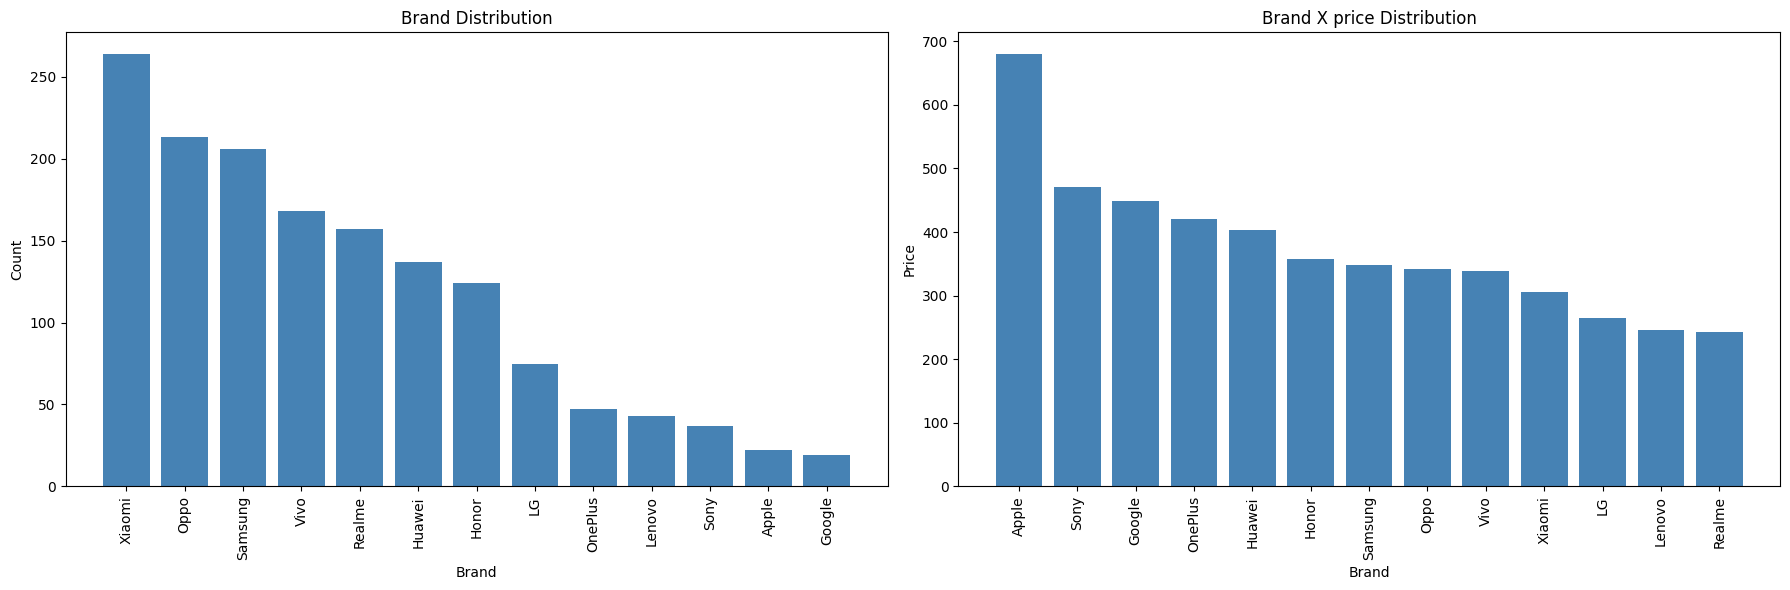

In [4]:
# Subtask 2a: Analyze number of phone types per brand and their average prices
# Draw one bar chart for phone types and another for average prices

# Count phone types per brand
brand_count = data.groupby('brand')['phone_name'].count().sort_values(ascending=False)

# Calculate average price per brand
brand_avg_price = data.groupby('brand')['price(USD)'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart for Brand Distribution (number of phone types)
axes[0].bar(brand_count.index, brand_count.values, color='steelblue')
axes[0].set_title('Brand Distribution')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Bar chart for Brand X price Distribution (average price per brand)
axes[1].bar(brand_avg_price.index, brand_avg_price.values, color='steelblue')
axes[1].set_title('Brand X price Distribution')
axes[1].set_xlabel('Brand')
axes[1].set_ylabel('Price')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [10]:
print(data.columns.tolist())

['phone_name', 'brand', 'os', 'inches', 'resolution', 'battery', 'battery_type', 'ram(GB)', 'announcement_date', 'weight(g)', 'storage(GB)', 'video_720p', 'video_1080p', 'video_4K', 'video_8K', 'video_30fps', 'video_60fps', 'video_120fps', 'video_240fps', 'video_480fps', 'video_960fps', 'price(USD)']


### Subtask 3: Analyze the correlation between video recording resolution and phone prices

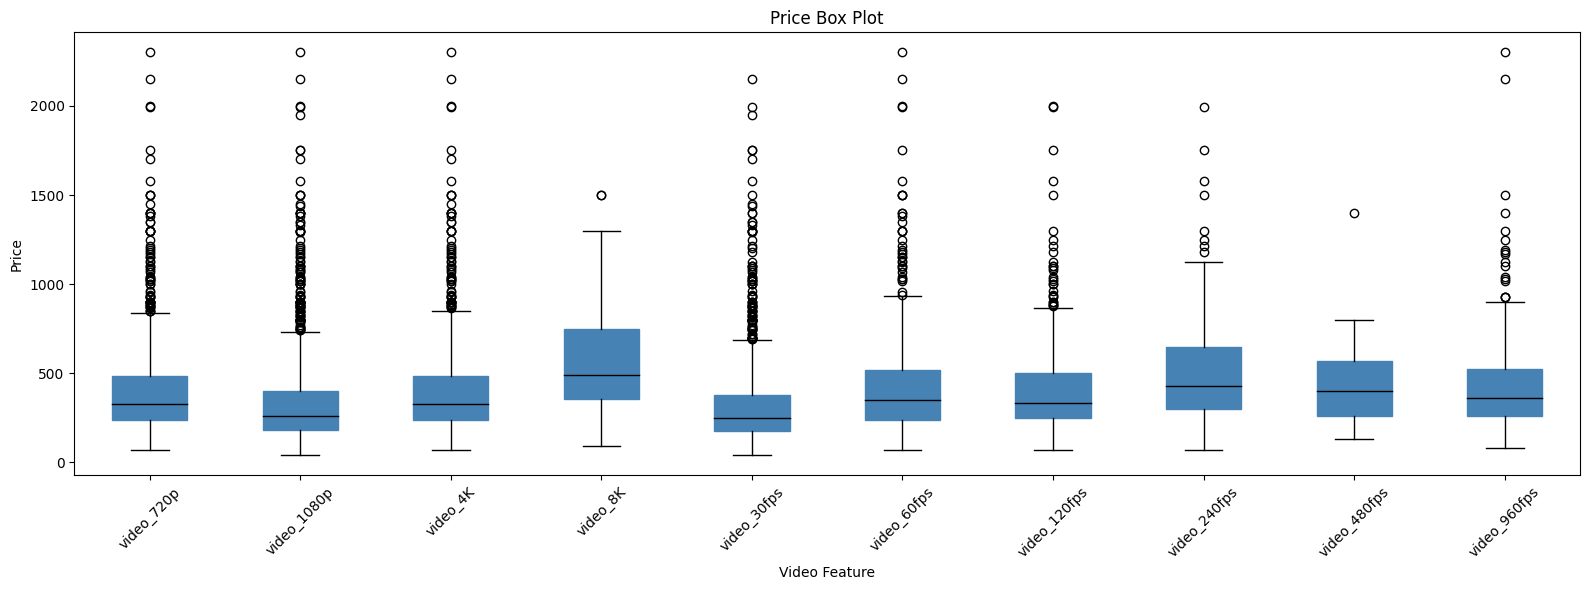

In [11]:
# The 10 video feature columns
video_cols = ['video_720p', 'video_1080p', 'video_4K', 'video_8K',
              'video_30fps', 'video_60fps', 'video_120fps', 'video_240fps',
              'video_480fps', 'video_960fps']

plt.figure(figsize=(16, 6))

# For each video feature, get prices where that feature == 1
video_groups = [data[data[col] == 1]['price(USD)'].dropna().values for col in video_cols]

plt.boxplot(video_groups, labels=video_cols, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='steelblue'),
            medianprops=dict(color='black'))
plt.title('Price Box Plot')
plt.xlabel('Video Feature')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 2: Preprocessing Structured Data (40 points)
### Subtask 1: Feature Filtering

In [6]:
# Subtask 1a: Copy the dataset, use price(USD) as label y
# Keep only inches, battery, ram(GB), weight(g), storage(GB) as features in X

df = data.copy()

# Label
y = df['price(USD)']

# Feature set X - keep only the specified columns
X = df[['inches', 'battery', 'ram(GB)', 'weight(g)', 'storage(GB)']]

print(X.head())

   inches  battery  ram(GB)  weight(g)  storage(GB)
0     5.0     2200        2      140.0           16
1     5.3     2700        2      140.0           16
2     5.2     3000        4      147.0           16
3     5.5     4100        4      165.0           32
4     5.1     3200        4      145.0           32


### Subtask 2: Normalize and encode the data features and label

In [7]:
# Subtask 2a: Write a function called 'preprocessing' for data preprocessing
# Use StandardScaler to normalize label y and features X
# Split into training set (80%) and test set (20%)
# Return features and labels of training and test sets

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def preprocessing(X, y):
    # Drop rows with missing values
    df_clean = pd.concat([X, y], axis=1).dropna()
    X_clean = df_clean[X.columns]
    y_clean = df_clean[y.name]

    # Normalize features
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_clean)

    # Normalize label
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y_clean.values.reshape(-1, 1))

    # Split into 80% training and 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_scaled, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test

# Apply preprocessing
X_train, X_test, y_train, y_test = preprocessing(X, y)

print('Number transactions x_train dataset: ', X_train.shape)
print('Number transactions y_train dataset: ', y_train.shape)
print('Number transactions x_test dataset: ', X_test.shape)
print('Number transactions y_test dataset: ', y_test.shape)

Number transactions x_train dataset:  (1209, 5)
Number transactions y_train dataset:  (1209, 1)
Number transactions x_test dataset:  (303, 5)
Number transactions y_test dataset:  (303, 1)


In [14]:
!pip install scikit-learn==0.24.2 --force-reinstall

Looking in indexes: http://repo.myhuaweicloud.com/repository/pypi/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 24.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 68.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 42.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 39.9 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.1.0
    Uninstalling threadpoolctl-3.1.0:
      Successfully uninstalled threadpoolctl-3.1.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.5
    Uninstalling numpy-1.19.5:
      Successfully uninstalled numpy-1.19.5
  Attempting uninstall: joblib
    Found existing installation: joblib 1.2.0
    Uninstalling joblib-1.2.0:
      Successfully uninstalled joblib-1.2.0
  Attempting uninstall: scipy
    Found existing installation: scipy 1.5.2
    Uninstalli

## Task 3: Training Models on Structured Data (80 points)
### Subtask 1: Import algorithms

In [16]:
# Subtask 1a: Import regression algorithms and store them in a list called 'models'
import importlib
import sklearn
importlib.reload(sklearn)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from xgboost import XGBRegressor

models = [
    ['KNeighbors', KNeighborsRegressor()],
    ['Random Forest', RandomForestRegressor()],
    ['SVM', SVR()],
    ['SGD', SGDRegressor()],
    ['GradientBoosting', GradientBoostingRegressor()],
    ['XGBoost', XGBRegressor()]
]

print(models)

AttributeError: type object 'sklearn.utils.arrayfuncs.array' has no attribute '__reduce_cython__'

### Subtask 2: Train models and calculate their accuracy

In [ ]:
# Subtask 2a: Train the models on the training set and evaluate accuracy on the test set
from sklearn.metrics import r2_score

y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

for name, model in models:
    model.fit(X_train, y_train_flat)
    score = model.score(X_test, y_test_flat)
    print(f'{name} accuracy (R2): {score:.6f}')

### Subtask 3: Evaluate models

In [ ]:
# Subtask 3a: Use MSE metrics to evaluate the models
# Draw the evaluation results in a DataFrame and print it
from sklearn.metrics import mean_squared_error

results = []
for name, model in models:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test_flat, y_pred)
    results.append({'Model': name, 'MSE': round(mse, 6)})

results_df = pd.DataFrame(results)
print(results_df)

### Subtask 4: Tune a model

In [ ]:
# Subtask 4a: Select one model and use GridSearchCV to tune the hyperparameters
# The tuned model should gain at least 5% improvement in MSE
from sklearn.model_selection import GridSearchCV

# Select KNeighborsRegressor for tuning
base_model = KNeighborsRegressor()
base_model.fit(X_train, y_train_flat)
base_mse = mean_squared_error(y_test_flat, base_model.predict(X_test))
print(f'KNeighbors base MSE: {base_mse:.6f}')

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train_flat)

best_model = grid_search.best_estimator_
tuned_mse = mean_squared_error(y_test_flat, best_model.predict(X_test))

improvement = (base_mse - tuned_mse) / base_mse * 100
print(f'Best parameters: {grid_search.best_params_}')
print(f'Tuned KNeighbors MSE: {tuned_mse:.6f}')
print(f'Improvement: {improvement:.2f}%')